# **Assignment 6: Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato or Soybean disease dataset**

In [ ]:
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# Download latest version
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomatoleaf' dataset.
Path to dataset files: /kaggle/input/tomatoleaf


In [ ]:
# KaggleHub downloaded dataset location
dataset_path = os.path.join(path, "tomato")

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

print("Dataset path:", dataset_path)

print("\nTraining classes:")
print(os.listdir(train_path))

print("\nValidation classes:")
print(os.listdir(val_path))

Dataset path: /kaggle/input/tomatoleaf/tomato

Training classes:
['Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Leaf_Mold', 'Tomato___Spider_mites Two-spotted_spider_mite']

Validation classes:
['Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Leaf_Mold', 'Tomato___Spider_mites Two-spotted_spider_mite']


In [ ]:
img_size = (128, 128)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [ ]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

print("Number of Classes:", len(class_names))

Classes:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of Classes: 10


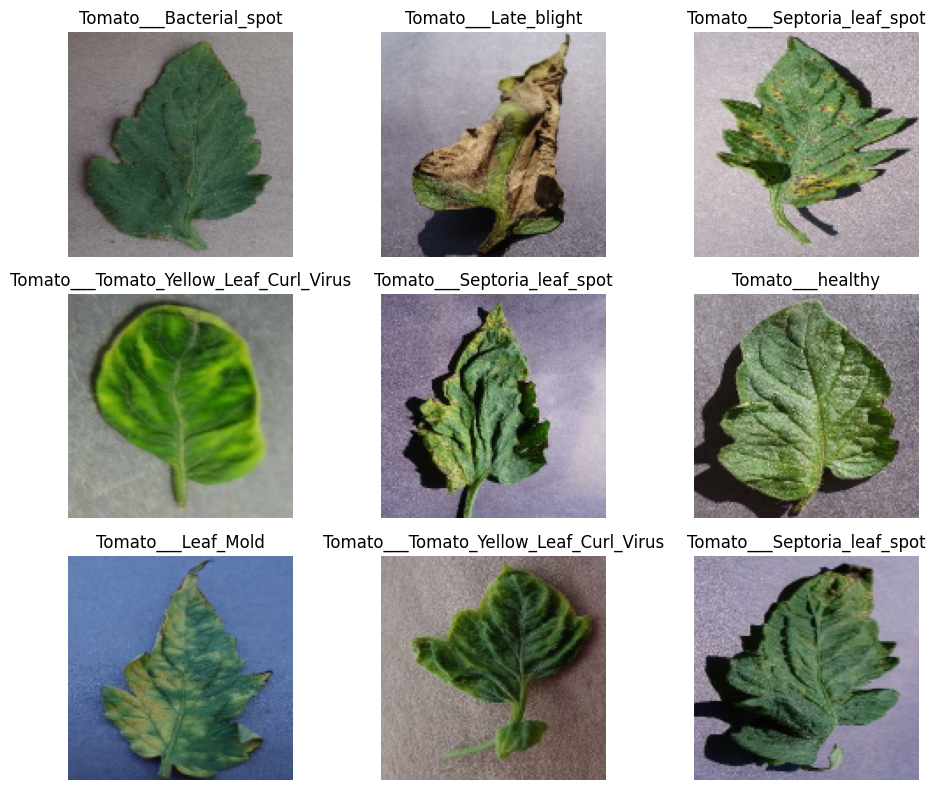

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(
        1./255,
        input_shape=(128, 128, 3)
    ),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
epochs = 5

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 301s 922ms/step - accuracy: 0.0981 - loss: 2.3032 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 284s 907ms/step - accuracy: 0.0982 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 909ms/step - accuracy: 0.0943 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 909ms/step - accuracy: 0.0932 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 910ms/step - accuracy: 0.0991 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026


In [ ]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.1000 - loss: 2.3026
Validation Loss: 2.3025925159454346
Validation Accuracy: 0.10000000149011612


In [ ]:
for images, labels in validation_dataset.take(1):

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(5):

        print(
            "Actual:",
            class_names[labels[i]],
            "| Predicted:",
            class_names[predicted_classes[i]]
        )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot
Actual: Tomato___Bacterial_spot | Predicted: Tomato___Target_Spot


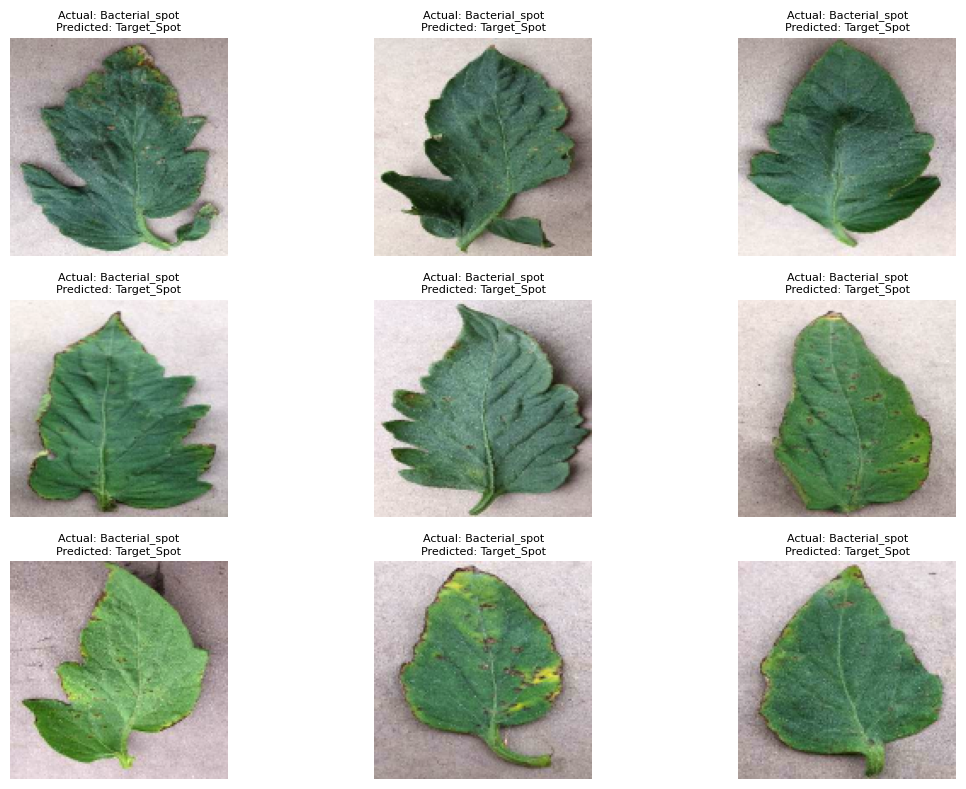

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    img = images[i].numpy()

    # Normalize ONLY for visualization
    img_display = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img_display)

    actual = class_names[labels[i]]
    predicted = class_names[predicted_classes[i]]

    actual = actual.replace("Tomato___", "")
    predicted = predicted.replace("Tomato___", "")

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

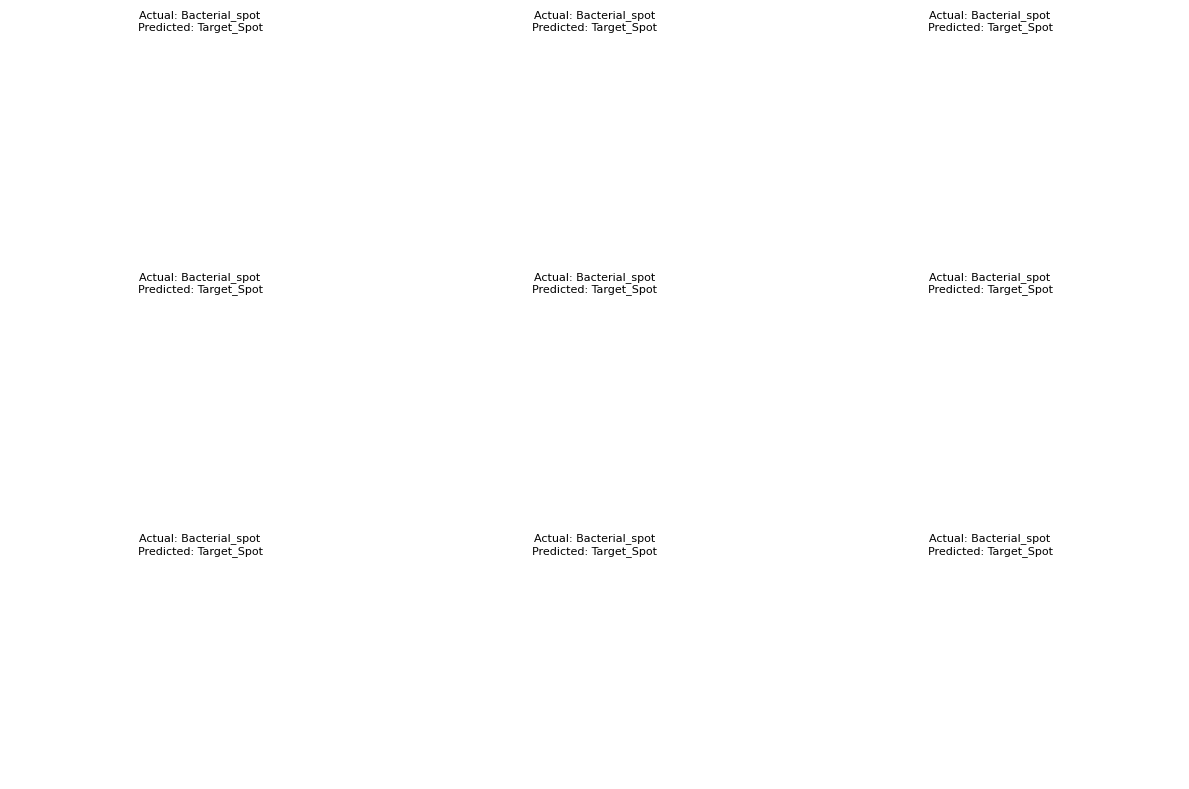

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    actual = class_names[labels[i]]
    predicted = class_names[predicted_classes[i]]

    actual = actual.replace("Tomato___", "")
    predicted = predicted.replace("Tomato___", "")

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
dataset_path = os.path.join(path, "tomato")

print(os.listdir(dataset_path))

['cnn_train.py', 'val', 'train']


In [ ]:
model.save("tomato_disease_cnn.keras")

In [ ]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", images[0].numpy().min())
    print("Maximum pixel value:", images[0].numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 0.80392164
